# Tutorial 14 -- Kerr Free Evolution

Prepare a coherent cavity state, let it evolve under self-Kerr in the matched rotating frame, and inspect the resulting phase-space dynamics.

**Prerequisites.** Tutorials 03, 05, and 08 are recommended first.


## 1. Goal

We will isolate self-Kerr evolution in the storage mode and visualize how the cavity moments and Wigner function change over time.


## 2. Physical Background

In the matched rotating frame, a cavity with self-Kerr no longer undergoes a large bare rotation, but it still accumulates number-dependent phase. The exact invariant in this closed system is `⟨n(t)⟩ = |alpha|^2`, while the Kerr phase shears the coherent-state trajectory in phase space.


## 3. Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    coherent_state,
    prepare_state,
    qubit_state,
    simulate_sequence,
)
from cqed_sim.sim import (
    cavity_wigner,
    mode_moments,
    reduced_cavity_state,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 4. Simulation Parameters


In [2]:
total_time = 20.0 * us
dt = 0.2 * us


## 5. Model Construction


In [3]:
initial_alpha = 1.8
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.05),
    omega_q=GHz(6.25),
    alpha=MHz(-220.0),
    chi=0.0,
    kerr=MHz(-0.080),
    n_cav=28,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
initial_state = prepare_state(
    model,
    StatePreparationSpec(qubit=qubit_state("g"), storage=coherent_state(initial_alpha)),
)


## 6. Pulse / Sequence Construction


In [4]:
compiled = SequenceCompiler(dt=dt).compile([], t_end=total_time)


## 7. Running the Simulation


In [5]:
result = simulate_sequence(
    model,
    compiled,
    initial_state,
    {},
    config=SimulationConfig(frame=frame, store_states=True, max_step=dt),
)
cavity_means = np.array([mode_moments(state, "storage")["a"] for state in result.states], dtype=np.complex128)
photon_numbers = np.array([mode_moments(state, "storage")["n"] for state in result.states], dtype=float)
expected_photon_number = np.full_like(photon_numbers, abs(initial_alpha) ** 2, dtype=float)
print(f"Maximum |<n> - |alpha|^2| = {np.max(np.abs(photon_numbers - expected_photon_number)):.3e}")


Maximum |<n> - |alpha|^2| = 4.003e-07


## 8. Visualizing the Results


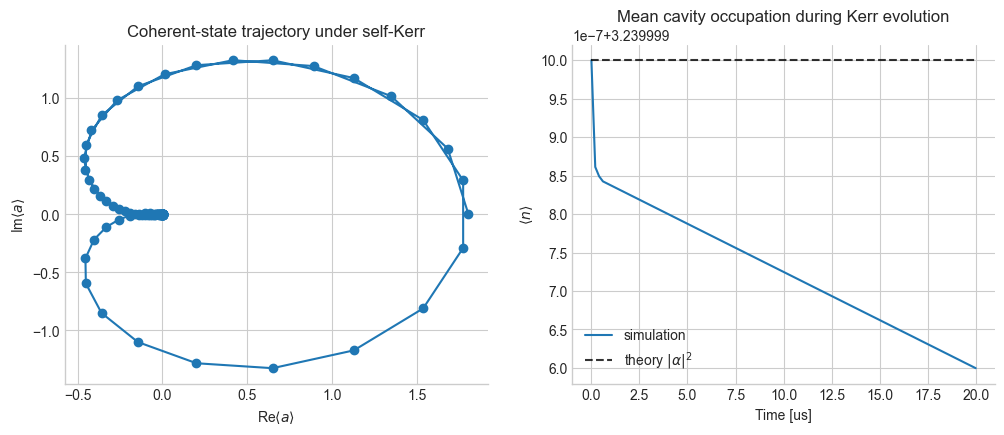

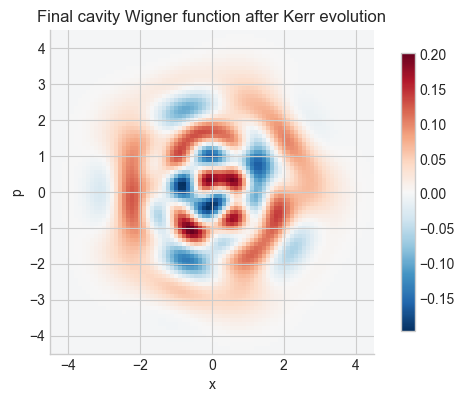

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].plot(np.real(cavity_means), np.imag(cavity_means), "o-")
axes[0].set_xlabel(r"Re$\langle a \rangle$")
axes[0].set_ylabel(r"Im$\langle a \rangle$")
axes[0].set_title("Coherent-state trajectory under self-Kerr")

axes[1].plot(compiled.tlist / us, photon_numbers, label="simulation")
axes[1].plot(compiled.tlist / us, expected_photon_number, "--", color="black", alpha=0.8, label=r"theory $|\alpha|^2$")
axes[1].set_xlabel("Time [us]")
axes[1].set_ylabel(r"$\langle n \rangle$")
axes[1].set_title("Mean cavity occupation during Kerr evolution")
axes[1].legend()
plt.show()

final_rho_c = reduced_cavity_state(result.final_state)
xvec, yvec, w = cavity_wigner(final_rho_c, n_points=81, extent=4.5)
fig, ax = plt.subplots()
image = ax.imshow(w, origin="lower", extent=[xvec[0], xvec[-1], yvec[0], yvec[-1]], cmap="RdBu_r", aspect="equal")
ax.set_xlabel("x")
ax.set_ylabel("p")
ax.set_title("Final cavity Wigner function after Kerr evolution")
fig.colorbar(image, ax=ax, shrink=0.86)
plt.show()


## 9. Physical Interpretation

The cavity photon number stays locked to `|alpha|^2` because the Hamiltonian is closed and number conserving. The visible change is purely phase-space shearing: different Fock components accumulate different phases even though the population distribution itself is unchanged.


## 10. Exercises / Next Steps

- Reverse the sign of the Kerr coefficient and compare the direction of the phase-space bending.
- Add a small cavity decay rate and observe how loss and Kerr compete.
- Continue to Tutorials 15 and 16 for cross-Kerr and lossy bosonic dynamics.
